 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submission 
Name           : Craig Lawson                <br>
Student Number : L00196711         <br>
Due Date       : May 12, 2026, 22:59 UTC                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
### High Level Flow
- Load Receipt images from dataset
- Apply preprocessing such as grayscale, thresholding and edge detection
- Use Tesseract OCR to extract text from images and from detected regions
- clean ocr text and apply NLP techniques like tokenization, lemmatisation stopword removal NER and TF-IDF keyword extraction
- Extract structured receipt fields such as merchant, date time and toatl
- Compine NLP output and CV output into a unified report
- batch process the remaining dataset and export a summary table for analysis

# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
# pip installs
%pip install opencv-python pytesseract pillow matplotlib numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
# imports
# Had to run sudo apt-get install -y libgl1 dependency for opencv
import os
import cv2
import pytesseract
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from pathlib import Path
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import spacy

# Load spaCy English model for NLP tasks
nlp = spacy.load("en_core_web_sm")

# Support Functions
#### Image preprocessing approach based on common OCR preprocessing techniques:
#### grayscale conversion, Gaussian blur, adaptive thresholding and Otsu thresholding.
Ref: https://pyimagesearch.com/2021/05/12/adaptive-thresholding-with-opencv-cv2-adaptivethreshold/

In [3]:
# code here
#Preprocess
def preprocess_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# this function allows us to change thresholding after applying grayscale and blur
def preprocess_adaptive(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    return cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

#applying OTSU thresholding after greyscale and blur
def preprocess_otsu(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return thresh

#OCR tet cleaning and field extraction fnctions
#splitting so there are non empty lines
def get_lines(text):
    return [line.strip() for line in text.splitlines()]

# Receipt field extraction logic was developed with assistance from GenAI (ChatGPT) assistance and manual testing.
# Regex patterns are used to identify common receipt fields such as dates, times and monetary totals.
# basic stripping from text before NLP
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

#Extracting merchant name from first OCR lines
def extract_merchant(text):
    lines = get_lines(text)

    for line in lines[:8]:
        cleaned = re.sub(r"[^A-Za-z0-9&' .-]", "", line).strip()

        if len(cleaned) < 4:
            continue

        # Avoidding lines that are clearly addresses, phone numbers or opening hours
        lower = cleaned.lower()
        if any(term in lower for term in ["store", "open", "daily", "ave", "street", "road", "phone"]):
            continue

        if any(char.isalpha() for char in cleaned):
            return cleaned

    return None

# finding common receipt date formats from patterns
def extract_date(text):
    patterns = [
        r"\b\d{2}[/-]\d{2}[/-]\d{4}\b",
        r"\b\d{2}[/-]\d{2}[/-]\d{2}\b",
        r"\b\d{4}[/-]\d{2}[/-]\d{2}\b"
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return match.group()

    return None

# extracting a likely transaction time while avoiding opening hours when possible
def extract_time(text):
    lines = get_lines(text)
    time_pattern = r"\b\d{1,2}:\d{2}\s?(?:AM|PM|am|pm)?\b"

    for line in lines:
        lower = line.lower()
        if any(word in lower for word in ["open", "daily", "hours"]):
            continue

        time_match = re.search(time_pattern, line)
        if time_match:
            return time_match.group()

    return None

#Cleaning OCR strings into consistent decimal format
def normalise_amount(amount_str):
    if not amount_str:
        return None

    amt = amount_str.replace("$", "")
    amt = amt.replace(" ", "")
    amt = amt.replace(",", ".")
    return amt

# Extarcting final total whilst trying to avoid subtotal when possible
def extract_total(text):
    lines = get_lines(text)

    # Prefer lines containing TOTAL but not SUBTOTAL
    for line in lines:
        lower = line.lower()
        if "total" in lower and "subtotal" not in lower:
            amounts = re.findall(r"[$]?\s*\d+[.,]\d{2}", line)
            if amounts:
                return normalise_amount(amounts[-1])

    # Fallback option choose the last amount in the document
    all_amounts = re.findall(r"[$]?\s*\d+[.,]\d{2}", text)
    if all_amounts:
        return normalise_amount(all_amounts[-1])

    return None

#extracting fields from the text utilizing the predefined helper functions above
def extract_receipt_fields(text, filename=None):
    return {
        "filename": filename,
        "merchant": extract_merchant(text),
        "date": extract_date(text),
        "time": extract_time(text),
        "total": extract_total(text),
        "ocr_text": text
    }


# Vision

## Sub Heading 1

In [4]:
# code here...
#Checking environment and images loading
print("cv2", cv2.__version__)
print("pytesseract", pytesseract.__version__)
img = cv2.imread('data/receipts/1.jpg')
print(img.shape)

cv2 4.13.0
pytesseract 0.3.13
(1024, 688, 3)


# setting up custom config and changing psm 4 or 6
oem is using legacy engine 1 is legacy 2 is new and 3 is hybrid

#### More aggressive threshold-based preprocessing did not consistently improve OCR performance on real-world receipt images. In several cases, raw or grayscale images produced cleaner OCR output, especially where background textures became exaggerated after thresholding.
##### psm 4 gray is good combo or 
##### psm 5 attempted too (Worst)
##### psm 12 = Sparse text with OSD. Attempted but 
#### psm 6 is the best with gray or original 
https://pyimagesearch.com/2021/11/15/tesseract-page-segmentation-modes-psms-explained-how-to-improve-your-ocr-accuracy/

In [5]:
import pytesseract

print(pytesseract.get_tesseract_version())

5.3.4


In [6]:
# Tesseract OCR configuration
# OEM 3 = default engine mode
# PSM 6 = assume a single uniform block of text, which works reasonably well for many receipts
custom_config = r'--oem 3 --psm 6'

# Convert the sample receipt image to text
sample_text = pytesseract.image_to_string(img, config=custom_config)

print(sample_text)

= og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB ee)
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES... 2.49
PKG SHREDDED MOZZARELLA CITE T — 9.99
EGGS 1 002 ORGANIC BROWN. Bale
BEANS GARBANZO 0.89
SPROUTED CA STYLE Pee)
A-AVOCADOS HASS BAG ACT 3.99
A-APPLE BAG JAZZ 2 LB el
A-PEPPER BELL EACH XL RED 0.99
GROCERY NON TAXABLE 0.98
2 @ 0.49
BANANAS ORGANIC 0.87
3FA —«@.0.29/EA
CREAMY SALTED PEANUT BUT TER 2.49
WHL WHT PITA BREAD 1.69
GROCERY NON TAXABLE 1,38
2 @ 0.69
SUBTOTAL $38 .68
TOTAL $38 .68
CASH $40.00
CHANGE $1.32
ITEMS 22 Higgins, Ryan
06-28-2014 12:34PM 0403 04 1346 4683
THANK YOU FOR SHOPPING AT
TRADER JOE'S
www. traderjoes .com



In [7]:
img = cv2.imread("data/receipts/1.jpg")

raw_text = pytesseract.image_to_string(img, config=custom_config)
gray_text = pytesseract.image_to_string(preprocess_gray(img), config=custom_config)
# adaptive_text = pytesseract.image_to_string(preprocess_adaptive(img), config=custom_config)
# otsu_text = pytesseract.image_to_string(preprocess_otsu(img), config=custom_config)

print("RAW OCR:\n", raw_text[:1000])
print("\n" + "="*80 + "\n")
print("GRAY OCR:\n", gray_text[:1000])
print("\n" + "="*80 + "\n")
# print("ADAPTIVE OCR:\n", adaptive_text[:1000])
# print("\n" + "="*80 + "\n")
# print("OTSU OCR:\n", otsu_text[:1000])

RAW OCR:
 = og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB ee)
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES... 2.49
PKG SHREDDED MOZZARELLA CITE T — 9.99
EGGS 1 002 ORGANIC BROWN. Bale
BEANS GARBANZO 0.89
SPROUTED CA STYLE Pee)
A-AVOCADOS HASS BAG ACT 3.99
A-APPLE BAG JAZZ 2 LB el
A-PEPPER BELL EACH XL RED 0.99
GROCERY NON TAXABLE 0.98
2 @ 0.49
BANANAS ORGANIC 0.87
3FA —«@.0.29/EA
CREAMY SALTED PEANUT BUT TER 2.49
WHL WHT PITA BREAD 1.69
GROCERY NON TAXABLE 1,38
2 @ 0.69
SUBTOTAL $38 .68
TOTAL $38 .68
CASH $40.00
CHANGE $1.32
ITEMS 22 Higgins, Ryan
06-28-2014 12:34PM 0403 04 1346 4683
THANK YOU FOR SHOPPING AT
TRADER JOE'S
www. traderjoes .com



GRAY OCR:
 5
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R

While adaptive and Otsu thresholding are commonly used to enhance text visibility, they introduced significant noise in images with complex backgrounds. In this dataset, simpler preprocessing techniques such as grayscale conversion produced more reliable OCR results.

In [8]:
# NLP helper function using spaCy
# spaCy tokenisation, lemmatisation and stopword filtering based on spaCy NLP pipeline guidance.
# Ref: https://spacy.io/usage/linguistic-features
def clean_with_nlp(text):
    """
    Tokenise, lemmatise, and remove stopwords/punctuation using spaCy.
    Returns a list of clean lemmatisation tokens
    """
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
        and len(token.text) > 1
    ]
    return tokens

sample_tokens = clean_with_nlp(clean_text(sample_text))
print("spaCy model loaded successfully.")
print("Sample clean tokens:", sample_tokens[:20])


spaCy model loaded successfully.
Sample clean tokens: ['og', 'trader', 'joe', 'greenville', 'ave', 'dallas', 'tx', 'store', 'open', 'daily', 'carrot', 'shred', 'oz', 'cucumber', 'persian', 'lb', 'ee', 'tomato', 'crush', 'salt']


# NER
SpaCys NER model identigies real-world entites such as organisations, dates, money and locations directly from OCR text

In [9]:
# Named Entity Recognition implementation based on spaCy entity recognition documentation
# Ref: https://spacy.io/usage/linguistic-features#named-entities
def run_ner(text):
    """
    Run spaCy NER on text and return a dict of entity types -> values found.
    Reference: https://spacy.io/usage/linguistic-features#named-entities
    """
    doc = nlp(text)
    entities = {}
    for ent in doc.ents:
        if ent.label_ not in entities:
            entities[ent.label_] = []
        entities[ent.label_].append(ent.text)
    return entities

ner_results = run_ner(sample_text)

print("=== Named Entities Found ===")
for label, values in ner_results.items():
    print(f"  {label:12s}: {values}")


=== Named Entities Found ===
  PERSON      : ['JOE', 'Greenville Ave', 'PEANUT', 'Ryan', "JOE'S"]
  DATE        : ['2001', '06-28-2014', '04 1346 4683']
  GPE         : ['Dallas']
  MONEY       : ['#403 -', '9.99\nEGGS 1 002', '38', '38', '40.00', '1.32']
  CARDINAL    : ['469', '334', '10', '1.59', '1.59', '2.69', '2.49', '0.89', '3.99', '2', '0.99', '0.98', '2', '0.87', '3FA', '2.49', '1.69', '1,38', '2', '22']
  ORG         : ['DAILY', 'ORGANIC OLD FASHIONED', 'PKG', 'TER', 'WHL']
  WORK_OF_ART : ['@.0.29/EA']


# TF-IDF feature Extraction
TF-IDF (Term Frequency-Inverse Document Frequency) scores words by how distinctive they are across a collection of documents. Here we apply it across multiple receipt images to surface key terms
Ref: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [10]:
# TF-IDF across actual receipt OCR outputs instead of dummy example documents

data_dir = "data/receipts"
image_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

# Use the first few receipts for demonstration
ocr_documents = []
document_labels = []

for path in image_files[:5]:
    img_doc = cv2.imread(path)
    if img_doc is None:
        continue

    gray_doc = preprocess_gray(img_doc)
    text_doc = pytesseract.image_to_string(gray_doc, config=custom_config)
    cleaned_doc = clean_text(text_doc)

    if cleaned_doc:
        ocr_documents.append(cleaned_doc)
        document_labels.append(os.path.basename(path))

vectorizer = TfidfVectorizer(max_features=20, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(ocr_documents)
feature_names = vectorizer.get_feature_names_out()

print("=== TF-IDF Top Terms Per Receipt ===")
for i, doc_label in enumerate(document_labels):
    scores = tfidf_matrix[i].toarray()[0]
    top_indices = scores.argsort()[::-1][:5]
    top_terms = [(feature_names[j], round(scores[j], 3)) for j in top_indices if scores[j] > 0]

    print(f"\n{doc_label}:")
    for term, score in top_terms:
        print(f"   {term:20s} TF-IDF: {score}")


=== TF-IDF Top Terms Per Receipt ===

0.jpg:
   subtotal             TF-IDF: 0.386
   items                TF-IDF: 0.386
   20                   TF-IDF: 0.386
   change               TF-IDF: 0.386
   48                   TF-IDF: 0.386

1.jpg:
   99                   TF-IDF: 0.616
   organic              TF-IDF: 0.46
   69                   TF-IDF: 0.371
   49                   TF-IDF: 0.308
   29                   TF-IDF: 0.247

10.jpg:
   16                   TF-IDF: 0.587
   ee                   TF-IDF: 0.463
   99                   TF-IDF: 0.393
   ae                   TF-IDF: 0.379
   ea                   TF-IDF: 0.19

11.jpg:
   99                   TF-IDF: 0.865
   69                   TF-IDF: 0.347
   29                   TF-IDF: 0.174
   ae                   TF-IDF: 0.174
   49                   TF-IDF: 0.144

12.jpg:
   17                   TF-IDF: 0.431
   18                   TF-IDF: 0.431
   75                   TF-IDF: 0.431
   tax                  TF-IDF: 0.358
   subtota

# Sentiment Analysis
Sentiment Analysis is less typical for recipts, buit is a valid NLP technique demonstrated here. TI could be applied to product reveiew text or document notes
Ref: https://textblob.readthedocs.io/en/dev/

In [11]:
def analyse_sentiment(text):
    """
    Perform sentiment analysis using TextBlob.
    Polarity:     -1.0 (negative) to +1.0 (positive)
    Subjectivity:  0.0 (objective) to  1.0 (subjective)
    Reference: https://textblob.readthedocs.io/en/dev/
    """
    blob = TextBlob(text)
    return {
        "polarity": round(blob.sentiment.polarity, 3),
        "subjectivity": round(blob.sentiment.subjectivity, 3),
        "assessment": "positive" if blob.sentiment.polarity > 0 else
                      "negative" if blob.sentiment.polarity < 0 else "neutral"
    }

sentiment = analyse_sentiment(sample_text)
print("=== Sentiment Analysis ===")
for k, v in sentiment.items():
    print(f"  {k:15s}: {v}")


=== Sentiment Analysis ===
  polarity       : 0.029
  subjectivity   : 0.279
  assessment     : positive


# Computer Vision Image processing and Feature Detection
## Image Preprocessing Comparison
Comparing raw, grayscale and Otsu thresholding across receipt images to find the most effective approach for OCR quality 

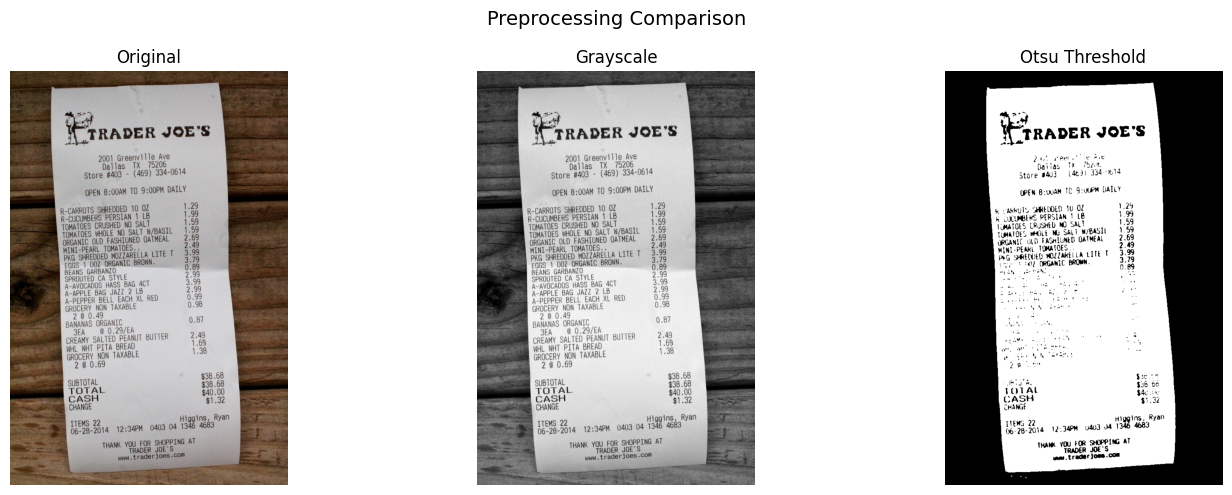


=== OCR Character Count Per Method ===
  Raw         : 835 characters
  Grayscale   : 835 characters
  Otsu        : 556 characters


In [12]:
def compare_preprocessing(image_path, config=r'--oem 3 --psm 6'):
    """
    Load an image and compare OCR output quality across three preprocessing methods.
    Returns a dict with character counts as a proxy for OCR completeness.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load: {image_path}")
        return None

    methods = {
        "Raw":        img,
        "Grayscale":  preprocess_gray(img),
        "Otsu":       preprocess_otsu(img)
    }

    results = {}
    for name, processed in methods.items():
        text = pytesseract.image_to_string(processed, config=config)
        results[name] = {"text": text, "char_count": len(text.strip())}

    return results

# Visualise the three preprocessing outputs side by side for visual comparison
def show_preprocessing_comparison(image_path):
    img = cv2.imread(image_path)
    gray  = preprocess_gray(img)
    otsu  = preprocess_otsu(img)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Preprocessing Comparison", fontsize=14)

    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(gray, cmap="gray")
    axes[1].set_title("Grayscale")
    axes[1].axis("off")

    axes[2].imshow(otsu, cmap="gray")
    axes[2].set_title("Otsu Threshold")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

#  Run on first receipt image 
show_preprocessing_comparison("data/receipts/1.jpg")

results = compare_preprocessing("data/receipts/1.jpg")
print("\n=== OCR Character Count Per Method ===")
for method, r in results.items():
    print(f"  {method:12s}: {r['char_count']} characters")


## Edge detection
Using the Canny algorithm highlights structural boundaries in the document to isolate the subject and remove any background that could cause noise when reading in the text from the receipt
ref:https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

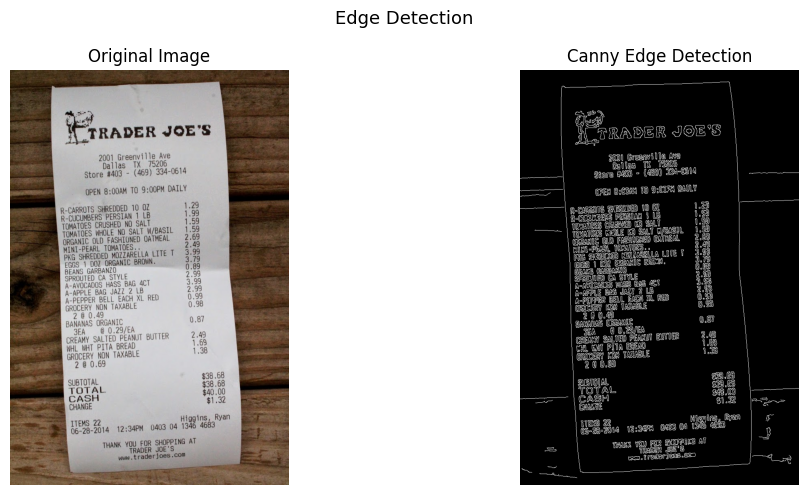

In [13]:
def detect_edges(img):
    """
    Apply Canny edge detection to a document image.
    Threshold values tuned for receipt/document images.
    Reference: https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
    return edges

img = cv2.imread("data/receipts/1.jpg")
edges = detect_edges(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edge Detection")
axes[1].axis("off")

plt.suptitle("Edge Detection", fontsize=13)
plt.tight_layout()
plt.show()


## Contour Detection Text block and region identification
Countours trace the boundaries of connected regions in an image. On a receipt each contour tupically corresponds to a line of text, allogo or a table cell
ref: https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html

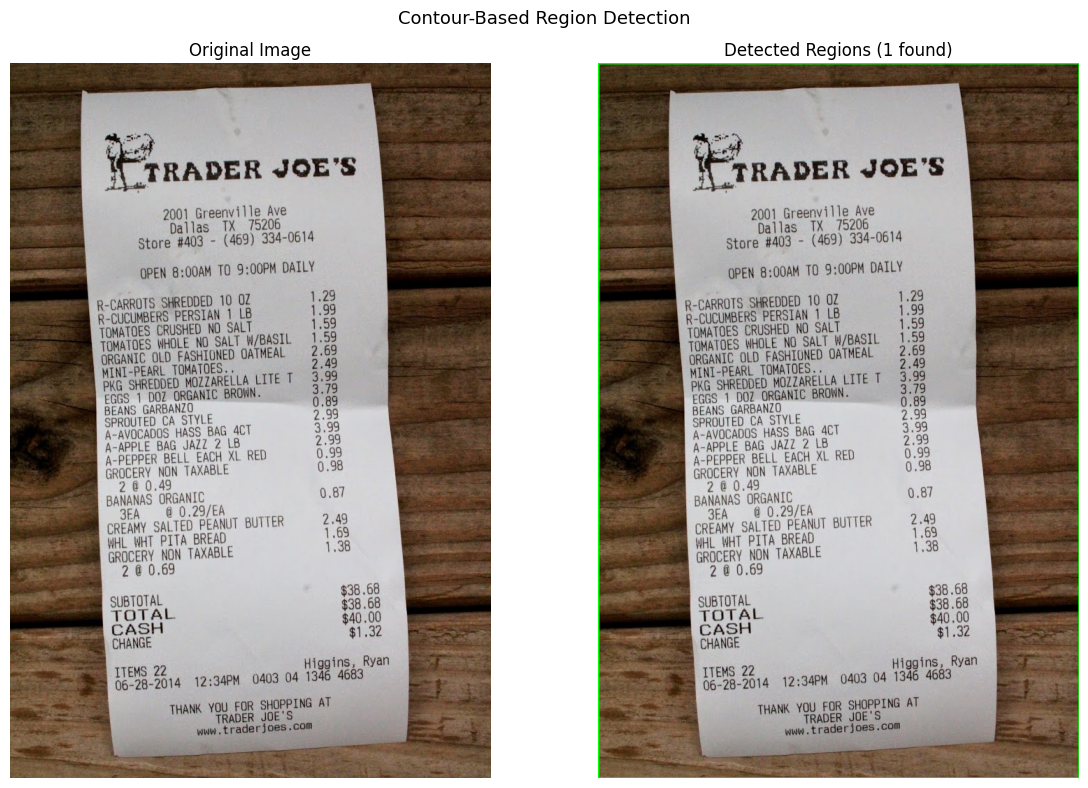

Total regions detected: 1


In [14]:
def detect_contours(img, min_area=500):
    """
    Detect contours in a document image and return bounding rectangles
    for regions larger than min_area pixels.
    Reference: https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Dilate to merge nearby text into blocks
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (18, 3))
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    regions = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        if w * h > min_area:
            regions.append((x, y, w, h))

    return regions

img = cv2.imread("data/receipts/1.jpg")
regions = detect_contours(img)

# Draw bounding boxes on a copy
img_annotated = img.copy()
for (x, y, w, h) in regions:
    cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detected Regions ({len(regions)} found)")
axes[1].axis("off")

plt.suptitle("Contour-Based Region Detection", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total regions detected: {len(regions)}")


## Image Segmentation Connected Components
Connected components analysis labels each distinct region of pixels, enabling us to isolate and count indicidual text lines, logos or other elements
ref: https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html

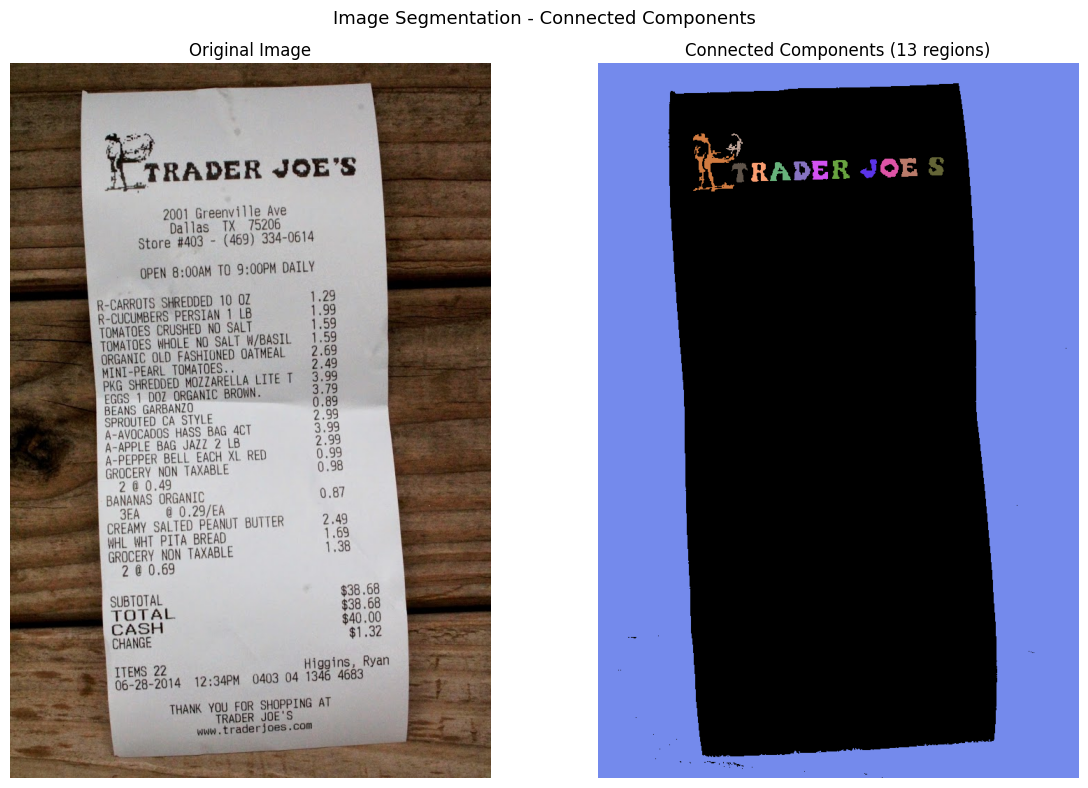

In [15]:
def segment_connected_components(img, min_area=200):
    """
    Use connected components to segment a document into labelled regions.
    Returns a coloured label map for visualisation.
    Reference: https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)

    # Build colour map — skipping label 0 (background)
    coloured = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    significant = 0
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_area:
            colour = np.random.randint(50, 255, size=3)
            coloured[labels == i] = colour
            significant += 1

    return coloured, significant

img = cv2.imread("data/receipts/1.jpg")
segmented, count = segment_connected_components(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(segmented)
axes[1].set_title(f"Connected Components ({count} regions)")
axes[1].axis("off")

plt.suptitle("Image Segmentation - Connected Components", fontsize=13)
plt.tight_layout()
plt.show()


# Multi-modal
Combinging the outputs of both NLP and CV pipeline to produce a unified understanding of each document. Detected image regions are matched with COR text extracted from those same regions linking visual structure and text

## Extracting Text Pre Visual Region
 Region-level OCR combines OpenCV-detected visual regions with Tesseract OCR.
 This multimodal structure was developed with GenAI guidance and manual testing.
 Ref: https://pypi.org/project/pytesseract/

In [16]:
def extract_text_from_regions(img, regions, config=r'--oem 3 --psm 6'):
    """
    For each detected bounding-box region, crop the image and run OCR.
    Returns a list of dicts with region coordinates and extracted text.
    """
    region_data = []
    for i, (x, y, w, h) in enumerate(regions):
        crop = img[y:y+h, x:x+w]
        text = pytesseract.image_to_string(crop, config=config).strip()
        if text:
            region_data.append({
                "region_id": i,
                "bbox": (x, y, w, h),
                "text": text,
                "char_count": len(text)
            })
    return region_data

img = cv2.imread("data/receipts/1.jpg")
regions = detect_contours(img)
region_data = extract_text_from_regions(img, regions)

print(f"=== Text Extracted from {len(region_data)} Regions ===")
for r in region_data[:6]:  # show first 6 for brevity
    print(f"\nRegion {r['region_id']} | bbox={r['bbox']}")
    print(f"  Text: {r['text'][:100]}")


=== Text Extracted from 1 Regions ===

Region 0 | bbox=(0, 0, 688, 1024)
  Text: = og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9


## Unified Document Analysis
 Full pipeline structure combining OCR, NLP and CV outputs was developed with GenAI (ChatGPT) guidance espcially whilst troubleshooting.


In [17]:
def analyse_document(image_path):
    """
    Full multi-modal pipeline for a single document image.
    Combines OCR, NLP, and computer vision outputs into one structured result.
    """
    print(f"\n{'='*60}")
    print(f"Analysing: {image_path}")
    print('='*60)

    # Step 1: Load image 
    img = cv2.imread(image_path)
    if img is None:
        print("ERROR: Could not load image.")
        return None

    # Step 2: Image preprocessing
    gray_img = preprocess_gray(img)
    print("Image preprocessed")

    # Step 3: OCR
    config = r'--oem 3 --psm 6'
    raw_text = pytesseract.image_to_string(gray_img, config=config)
    print(f"OCR complete — {len(raw_text.strip())} characters extracted")

    # Step 4: NLP 
    cleaned = clean_text(raw_text)
    tokens  = clean_with_nlp(cleaned)
    fields  = extract_receipt_fields(raw_text, filename=image_path)
    ner     = run_ner(raw_text)
    sent    = analyse_sentiment(raw_text)
    print(f"NLP complete — {len(tokens)} tokens, {len(ner)} entity types found")

    # Step 5: Computer vision — contours 
    regions = detect_contours(img)
    region_data = extract_text_from_regions(img, regions)
    print(f"Vision complete — {len(regions)} regions detected")

    return {
        "image_path":    image_path,
        "ocr_text":      raw_text,
        "tokens":        tokens,
        "fields":        fields,
        "ner":           ner,
        "sentiment":     sent,
        "regions":       region_data,
        "region_count":  len(regions)
    }

# Run on a single receipt
result = analyse_document("data/receipts/1.jpg")



Analysing: data/receipts/1.jpg
Image preprocessed
OCR complete — 835 characters extracted
NLP complete — 83 tokens, 6 entity types found
Vision complete — 1 regions detected


# Final Output

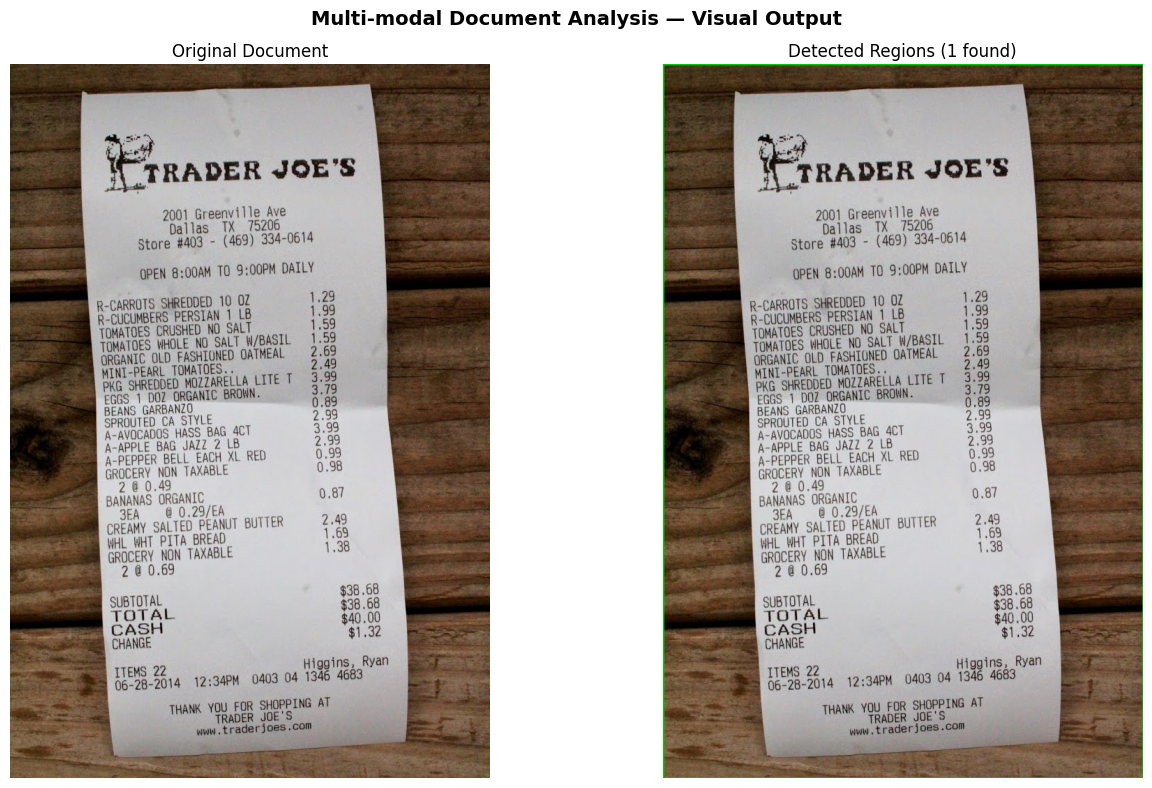


  STRUCTURED DOCUMENT REPORT
  File       : data/receipts/1.jpg
  Merchant   : TRADER JOES
  Date       : 06-28-2014
  Time       : 12:34PM
  Total      : 1.32
  Regions    : 1
  Tokens     : 83

── Named Entities ──
  CARDINAL    : 5, 469, 334
  PERSON      : JOE, Greenville Ave, Ryan
  DATE        : 2001, 06-28-2014, 04 1346 4683
  GPE         : Dallas
  MONEY       : #403 -, 38.68, 38
  ORG         : DAILY, ORGANIC OLD FASHIONED, PKG

── Sentiment ──
  Polarity     : 0.029  (positive)
  Subjectivity : 0.279

── Top NLP Tokens ──
  ['trader', 'joe', 'greenville', 'ave', 'dallas', 'tx', 'store', 'open', 'daily', 'carrot', 'shred', 'oz', 'cucumber', 'persian', 'lb']

── OCR Preview ──
5
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB 1.99
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES. . 2.49
PK


In [18]:
def display_final_report(result):
    """
    Display a comprehensive visual and textual report for a processed document.
    """
    if result is None:
        print("No result to display.")
        return

    img_orig = cv2.imread(result["image_path"])
    img_annotated = img_orig.copy()

    # Draw region bounding boxes on the annotated image
    for r in result["regions"]:
        x, y, w, h = r["bbox"]
        cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 200, 0), 2)

    # Visual display
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    axes[0].imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Document", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Detected Regions ({result['region_count']} found)", fontsize=12)
    axes[1].axis("off")

    plt.suptitle("Multi-modal Document Analysis — Visual Output", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Text report
    f = result["fields"]
    print("\n" + "="*60)
    print("  STRUCTURED DOCUMENT REPORT")
    print("="*60)
    print(f"  File       : {result['image_path']}")
    print(f"  Merchant   : {f.get('merchant', 'N/A')}")
    print(f"  Date       : {f.get('date', 'N/A')}")
    print(f"  Time       : {f.get('time', 'N/A')}")
    print(f"  Total      : {f.get('total', 'N/A')}")
    print(f"  Regions    : {result['region_count']}")
    print(f"  Tokens     : {len(result['tokens'])}")

    print("\n── Named Entities ──")
    if result["ner"]:
        for label, vals in result["ner"].items():
            print(f"  {label:12s}: {', '.join(vals[:3])}")
    else:
        print("  None detected")

    print("\n── Sentiment ──")
    s = result["sentiment"]
    print(f"  Polarity     : {s['polarity']}  ({s['assessment']})")
    print(f"  Subjectivity : {s['subjectivity']}")

    print("\n── Top NLP Tokens ──")
    print(f"  {result['tokens'][:15]}")

    print("\n── OCR Preview ──")
    print(result["ocr_text"][:300])
    print("="*60)

display_final_report(result)


## Batch Processing all images
Running a full pipeline across all images in the dataset and printing a summary table

In [19]:
# Batch Processing all images
# Running the full pipeline across the image dataset and building a summary table.

data_dir = "data/receipts"
image_files = sorted([
    os.path.join(data_dir, f)
    for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Found {len(image_files)} document images.\n")
print(f"{'File':<20} {'Merchant':<25} {'Date':<12} {'Total':<8} {'Regions':<8} {'Tokens'}")
print("-" * 90)

batch_results = []
for path in image_files[:5]:  # remove [:5] to process the full dataset
    r = analyse_document(path)
    if r:
        batch_results.append(r)
        f = r["fields"]
        fname = os.path.basename(path)
        print(f"{fname:<20} {str(f.get('merchant','N/A')):<25} {str(f.get('date','N/A')):<12} "
              f"{str(f.get('total','N/A')):<8} {r['region_count']:<8} {len(r['tokens'])}")

print(f"\nProcessed {len(batch_results)} documents successfully.")

Found 20 document images.

File                 Merchant                  Date         Total    Regions  Tokens
------------------------------------------------------------------------------------------

Analysing: data/receipts/0.jpg
Image preprocessed


OCR complete — 344 characters extracted
NLP complete — 34 tokens, 5 entity types found
Vision complete — 18 regions detected
0.jpg                ALMART                    None         5.89     18       34

Analysing: data/receipts/1.jpg
Image preprocessed
OCR complete — 835 characters extracted
NLP complete — 83 tokens, 6 entity types found
Vision complete — 1 regions detected
1.jpg                TRADER JOES               06-28-2014   1.32     1        83

Analysing: data/receipts/10.jpg
Image preprocessed
OCR complete — 1218 characters extracted
NLP complete — 169 tokens, 10 entity types found
Vision complete — 1 regions detected
10.jpg               ABR Sitar ienltatt gs Mae i None         338.16   1        169

Analysing: data/receipts/11.jpg
Image preprocessed
OCR complete — 562 characters extracted
NLP complete — 64 tokens, 7 entity types found
Vision complete — 42 regions detected
11.jpg               - ree                     None         45.44    42       64

Analysing: data/

In [20]:
# Inspect the first batch result to confirm the output structure
if batch_results:
    print(batch_results[0].keys())
    batch_results[0]
else:
    print("No batch results available yet.")


dict_keys(['image_path', 'ocr_text', 'tokens', 'fields', 'ner', 'sentiment', 'regions', 'region_count'])


In [21]:
# Flatten the batch results into a clean summary DataFrame
flat_results = []

for r in batch_results:
    f = r.get("fields", {})

    flat_results.append({
        "filename": os.path.basename(r.get("image_path", "")),
        "merchant": f.get("merchant"),
        "date": f.get("date"),
        "time": f.get("time"),
        "total": f.get("total"),
        "region_count": r.get("region_count"),
        "token_count": len(r.get("tokens", []))
    })

df_summary = pd.DataFrame(flat_results)
display(df_summary)

# saving output for final submission evidence
output_path = "receipt_analysis_summary.csv"
df_summary.to_csv(output_path, index=False)
print(f"Saved summary to {output_path}")


,filename,merchant,date,time,total,region_count,token_count
0,0.jpg,ALMART,NaN,NaN,5.89,18,34
1,1.jpg,TRADER JOES,06-28-2014,12:34PM,1.32,1,83
2,10.jpg,ABR Sitar ienltatt gs Mae i,NaN,16:17,338.16,1,169
3,11.jpg,- ree,NaN,NaN,45.44,42,64
4,12.jpg,WE SELL FOR LESS,10/20/07,13:48,18.75,34,43


Saved summary to receipt_analysis_summary.csv


# References/ Resources used
- https://pyimagesearch.com/2021/05/12/adaptive-thresholding-with-opencv-cv2-adaptivethreshold/
- https://pyimagesearch.com/2021/11/15/tesseract-page-segmentation-modes-psms-explained-how-to-improve-your-ocr-accuracy/
- https://spacy.io/usage/linguistic-features#named-entities
- https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
- https://textblob.readthedocs.io/en/dev/
- https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
- https://docs.opencv.org/4.x/d4/d73/tutorial_py_contours_begin.html
- https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html
- https://pypi.org/project/pytesseract/
- https://spacy.io/models/en
